# STA 141A: Predicting Wildfire Incidence in the United States


Produced by: Sufiyah Ezatullah


---

### 0. Abstract
Wildfires pose increasing risks to ecosystems, communities, and public safety, making it important to better understand patterns of wildfire occurrence over time and across geographic regions. This project analyzes historical wildfire data to identify patterns in wildfire activity and to develop predictive models that estimate the likelihood of a notable wildfire occurring within a county during a given month. The analysis uses a sample dataset (wildfires_sample_100k.csv) derived from the Kaggle dataset *“1.88 Million US Wildfires”*. The dataset includes wildfire ignition locations, discovery dates, containment dates, and final burned area across the contiguous United States.. A sampled version of the dataset was used to make the analysis computationally feasible while still preserving the key spatial and temporal patterns in wildfire activity.

The dataset was aggregated into a county-by-month panel structure that captures both geographic variation and changes over time. Predictors were constructed using historical wildfire information, including lagged fire counts, burned area, and rolling summaries of recent wildfire activity. A notable wildfire was defined as a fire with a burned area of at least 300 acres, and the prediction task was formulated as a binary classification problem indicating whether at least one notable wildfire occurred in a county during a given month.

Two predictive models were developed to estimate wildfire risk: a logistic regression model as a baseline and a random forest model as a more flexible machine learning approach. To ensure realistic model evaluation, a time-aware validation strategy was used in which models were trained on earlier years of data and tested on future years, preventing data leakage from future observations. Model performance was evaluated using the Area Under the Receiver Operating Characteristic Curve (AUC).

The results show that the logistic regression model consistently outperformed the random forest model across validation years, achieving a higher average AUC and stronger predictive performance in the final holdout evaluation. These findings suggest that relatively simple statistical models can effectively capture important patterns in wildfire occurrence when historical wildfire activity is used as a predictor. Overall, the analysis demonstrates how historical wildfire data can be used to build predictive models that help characterize wildfire risk across both space and time.

### 1. Data Preprocessing

This section should clearly explain how the raw wildfire data are transformed into the final dataset used for modeling.

The report should explain
- How notable fires are identified and filtered  
- How space–time units are constructed (e.g., grid-by-month)  
- How the binary outcome variable is defined  
- How predictors are constructed or aggregated  
- How missing data or edge cases are handled  

**Minimum required output:** A summary table describing the final dataset used for predictive modeling. 

In [4]:
fires_raw <- read_csv("wildfires_sample_100k.csv", show_col_types = FALSE)

glimpse(fires_raw)

Rows: 100,000
Columns: 39
$ OBJECTID                   <dbl> 16, 68, 73, 111, 191, 228, 264, 269, 294, 3…
$ FOD_ID                     <dbl> 16, 68, 74, 112, 194, 231, 268, 274, 299, 3…
$ FPA_ID                     <chr> "FS-1418876", "FS-1419017", "FS-1419045", "…
$ SOURCE_SYSTEM_TYPE         <chr> "FED", "FED", "FED", "FED", "FED", "FED", "…
$ SOURCE_SYSTEM              <chr> "FS-FIRESTAT", "FS-FIRESTAT", "FS-FIRESTAT"…
$ NWCG_REPORTING_AGENCY      <chr> "FS", "FS", "FS", "FS", "FS", "FS", "FS", "…
$ NWCG_REPORTING_UNIT_ID     <chr> "USCAENF", "USMTKNF", "USMTKNF", "USCASNF",…
$ NWCG_REPORTING_UNIT_NAME   <chr> "Eldorado National Forest", "Kootenai Natio…
$ SOURCE_REPORTING_UNIT      <chr> "0503", "0114", "0114", "0515", "0302", "03…
$ SOURCE_REPORTING_UNIT_NAME <chr> "Eldorado National Forest", "Kootenai Natio…
$ LOCAL_FIRE_REPORT_ID       <chr> "103", "43", "33", "2", "279", "16", "37", …
$ LOCAL_INCIDENT_ID          <chr> "22", "015", "008", "01", "279", "06", "014…
$ FIRE_CODE   

In [5]:
install.packages("tidyverse")
install.packages("lubridate")
install.packages("zoo")
install.packages("pROC")
install.packages("randomForest")
install.packages("broom")
install.packages("scales")

library(tidyverse)
library(lubridate)
library(zoo)
library(pROC)
library(randomForest)
library(broom)
library(scales)

theme_set(theme_minimal())
set.seed(141)



The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages

The downloaded binary packages are in
	/var/folders/y7/3wwmpy2x7dz5h7ntr_d_gxx40000gn/T//RtmpswH2PD/downloaded_packages


In [6]:
# Convert Julian dates to standard Date format
fires <- fires_raw %>%
  mutate(
    discovery_date = as.Date(DISCOVERY_DATE - 2440587.5, origin = "1970-01-01"),
    containment_date = as.Date(CONT_DATE - 2440587.5, origin = "1970-01-01"),
    year = year(discovery_date),
    month = month(discovery_date),
    ym = floor_date(discovery_date, unit = "month")
  )

# Use 300 acres as the cutoff for a notable wildfire
# This follows the project description's recommended threshold
notable_cutoff <- 300

fires <- fires %>%
  mutate(
    notable_fire = as.integer(FIRE_SIZE >= notable_cutoff)
  )

# Keep only records with enough information to assign county and month
fires_clean <- fires %>%
  filter(
    !is.na(discovery_date),
    !is.na(FIPS_CODE),
    !is.na(FIPS_NAME),
    !is.na(STATE),
    !is.na(LATITUDE),
    !is.na(LONGITUDE)
  ) %>%
  mutate(
    county_fips = as.integer(FIPS_CODE),
    county_id = paste0(STATE, "_", sprintf("%03d", county_fips))
  )

# County-level lookup table for later joins
county_lookup <- fires_clean %>%
  group_by(county_id) %>%
  summarise(
    state = first(STATE),
    county_name = names(sort(table(FIPS_NAME), decreasing = TRUE))[1],
    county_lat = mean(LATITUDE, na.rm = TRUE),
    county_lon = mean(LONGITUDE, na.rm = TRUE),
    .groups = "drop"
  )

# Aggregate fire information to county-by-month
county_month <- fires_clean %>%
  group_by(county_id, ym) %>%
  summarise(
    year = first(year),
    month = first(month),
    n_fires = n(),
    n_notable = sum(notable_fire, na.rm = TRUE),
    total_fire_size = sum(FIRE_SIZE, na.rm = TRUE),
    max_fire_size = max(FIRE_SIZE, na.rm = TRUE),
    avg_fire_size = mean(FIRE_SIZE, na.rm = TRUE),
    outcome = as.integer(sum(notable_fire, na.rm = TRUE) > 0),
    .groups = "drop"
  )

# Build a full county-month panel so that months with no notable fire are included
all_months <- tibble(
  ym = seq(min(fires_clean$ym), max(fires_clean$ym), by = "month")
)

panel <- crossing(
  county_id = unique(county_lookup$county_id),
  ym = all_months$ym
) %>%
  left_join(county_lookup, by = "county_id") %>%
  left_join(county_month, by = c("county_id", "ym")) %>%
  mutate(
    year = if_else(is.na(year), year(ym), year),
    month = if_else(is.na(month), month(ym), month),
    n_fires = replace_na(n_fires, 0),
    n_notable = replace_na(n_notable, 0),
    total_fire_size = replace_na(total_fire_size, 0),
    max_fire_size = replace_na(max_fire_size, 0),
    avg_fire_size = replace_na(avg_fire_size, 0),
    outcome = replace_na(outcome, 0)
  ) %>%
  arrange(county_id, ym)

# Create lagged and rolling predictors using only past information
# This avoids leakage from future months
panel <- panel %>%
  group_by(county_id) %>%
  arrange(ym, .by_group = TRUE) %>%
  mutate(
    fires_lag1 = lag(n_fires, 1, default = 0),
    notable_lag1 = lag(n_notable, 1, default = 0),
    size_lag1 = lag(total_fire_size, 1, default = 0),

    fires_roll3 = lag(rollsum(n_fires, 3, fill = 0, align = "right"), 1, default = 0),
    notable_roll3 = lag(rollsum(n_notable, 3, fill = 0, align = "right"), 1, default = 0),
    size_roll3 = lag(rollsum(total_fire_size, 3, fill = 0, align = "right"), 1, default = 0),

    fires_roll12 = lag(rollsum(n_fires, 12, fill = 0, align = "right"), 1, default = 0),
    notable_roll12 = lag(rollsum(n_notable, 12, fill = 0, align = "right"), 1, default = 0),
    size_roll12 = lag(rollsum(total_fire_size, 12, fill = 0, align = "right"), 1, default = 0),

    cumulative_notable_prior = lag(cumsum(n_notable), 1, default = 0)
  ) %>%
  ungroup()

# Drop the first 12 months so rolling variables are more stable
panel_model <- panel %>%
  filter(ym >= (min(ym) %m+% months(12))) %>%
  mutate(
    month_factor = factor(month),
    state_factor = factor(state),
    outcome_factor = factor(outcome, levels = c(0, 1))
  )

# Required summary table for the final modeling dataset
dataset_summary <- tibble(
  n_observations = nrow(panel_model),
  n_counties = n_distinct(panel_model$county_id),
  start_month = min(panel_model$ym),
  end_month = max(panel_model$ym),
  positive_rate = mean(panel_model$outcome),
  spatial_unit = "County",
  temporal_unit = "Month",
  notable_fire_cutoff = paste0(notable_cutoff, " acres")
)

dataset_summary

n_observations,n_counties,start_month,end_month,positive_rate,spatial_unit,temporal_unit,notable_fire_cutoff
<int>,<int>,<date>,<date>,<dbl>,<chr>,<chr>,<chr>
658260,2385,1993-01-01,2015-12-01,0.001140887,County,Month,300 acres


A notable wildfire was defined as a fire with a final burned area of at least 300 acres, following the recommended cutoff in the project description. Records below this threshold were not considered notable events for the prediction task. Counties were chosen as the spatial unit and months as the temporal unit, creating a county-by-month panel dataset. For each county-month combination, the binary outcome variable equals 1 if at least one notable wildfire occurred during that month and 0 otherwise. Predictors were constructed from historical wildfire activity, including lagged counts of fires, lagged burned area, and rolling summaries over the previous three and twelve months. These variables capture recent wildfire history and help the model learn temporal patterns. Records missing key information such as county, state, date, or geographic location were removed because they could not be reliably assigned to a county-month unit.

The summary table describes the final dataset used for modeling. The dataset contains 658,260 county-month observations across 2,385 counties, covering the period from January 1993 to December 2015. Each row represents a single county in a specific month, which allows the model to predict whether a notable wildfire occurred in that location during that time period. The positive rate of approximately 0.00114 indicates that notable wildfires are relatively rare events, meaning only about 0.11 percent of county-month observations contain a notable fire. The table also confirms that the spatial unit is county and the temporal unit is month, with a notable fire defined using the 300-acre cutoff. This summary provides an overview of the scale and structure of the dataset used in the predictive modeling stage.

### 2. Exploratory Data Analysis  

The purpose of this section is to build intuition about the data and to justify modeling decisions.

You may explore questions such as

- How does wildfire incidence vary across space?
- How strong is seasonality?
- How do predictors differ between fire and non-fire observations?
- Are there trends over time?


**Minimum required output:** The report should include at least **two** exploratory plots that demonstrate the spatial and temporal patterns of wildfires. Each plot should be accompanied by a brief interpretation.


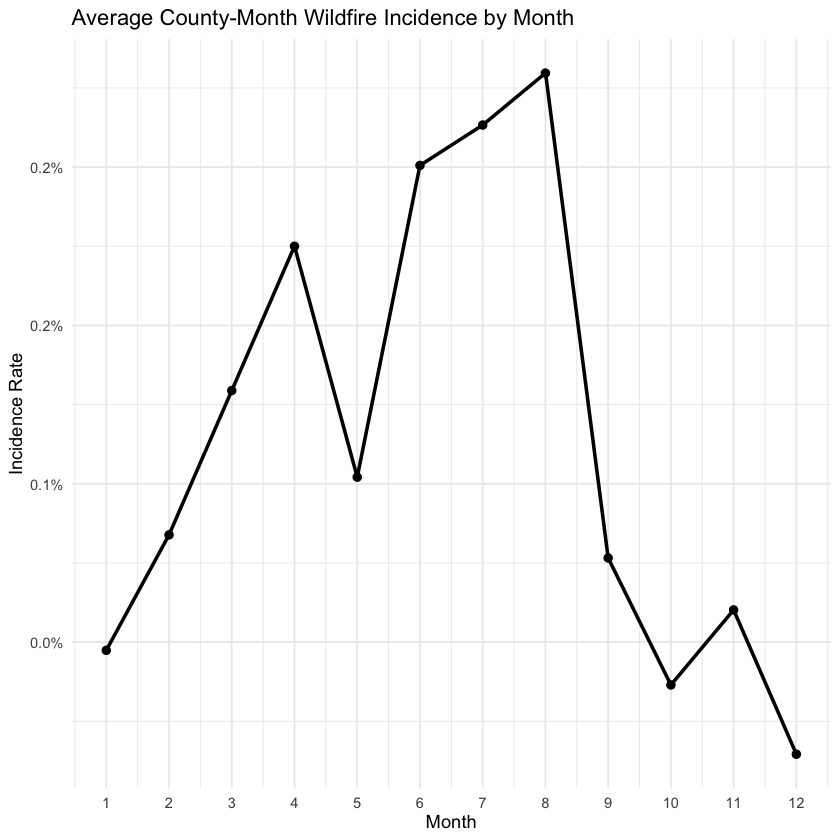

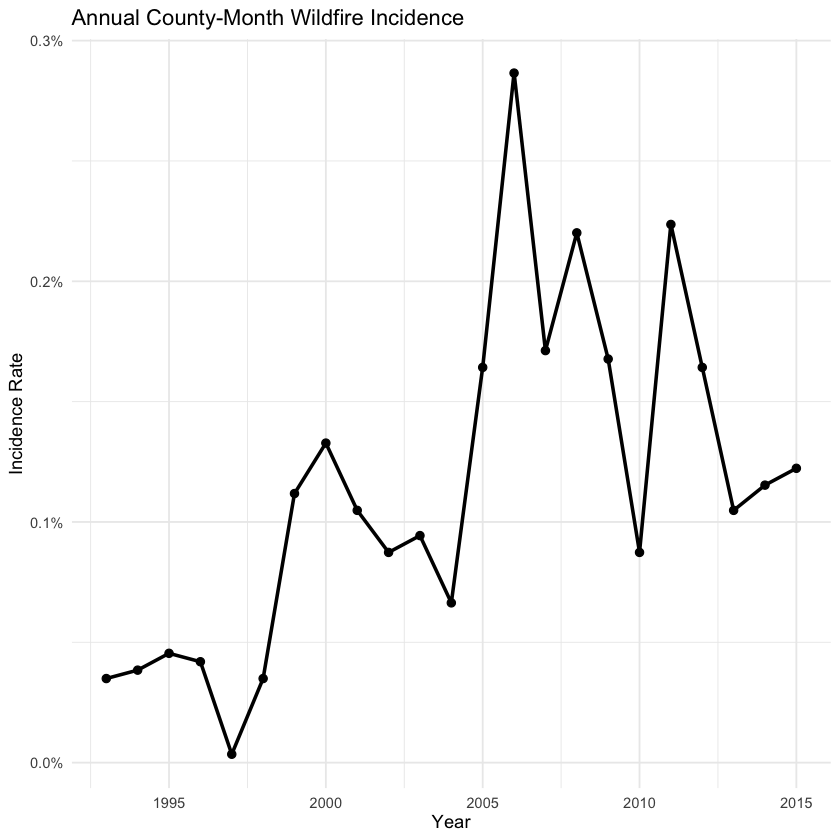

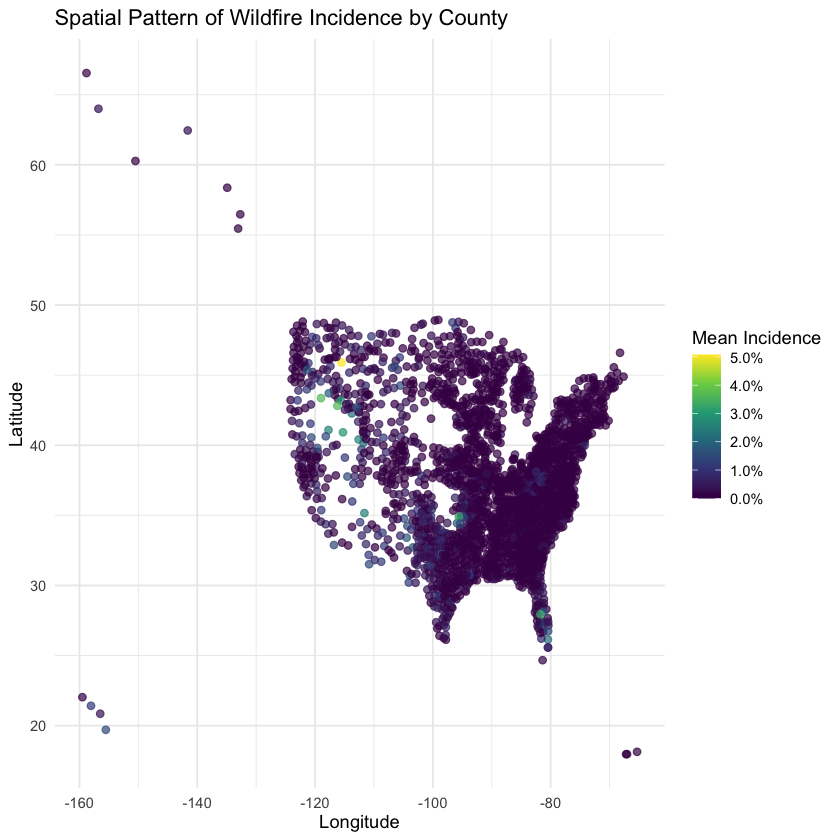

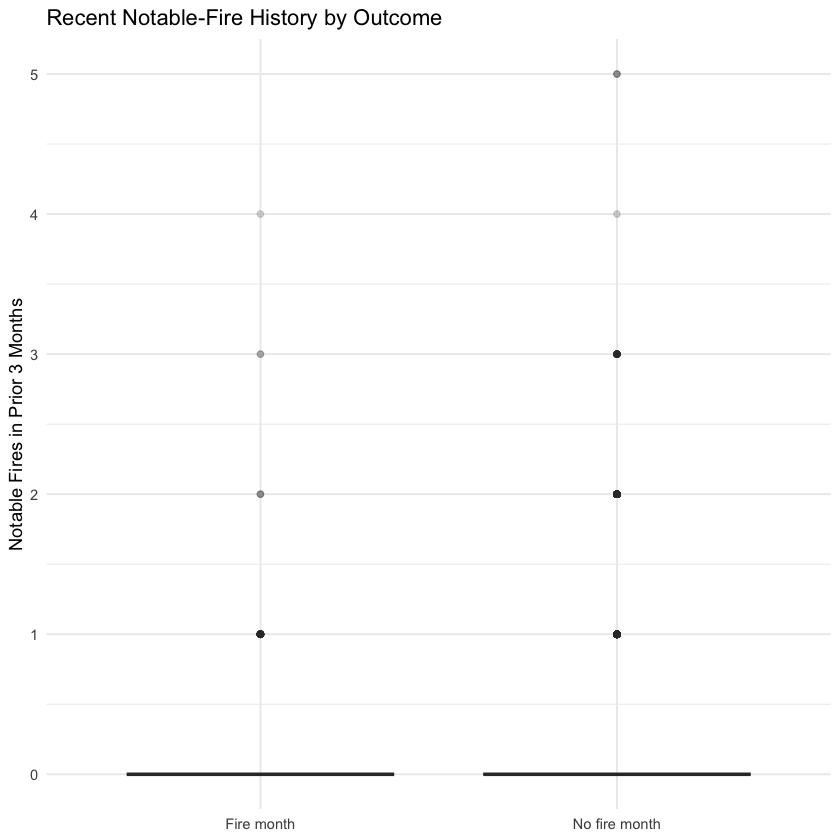

In [7]:
# Plot 1: seasonality across months
monthly_incidence <- panel_model %>%
  group_by(month) %>%
  summarise(
    incidence_rate = mean(outcome),
    .groups = "drop"
  )

ggplot(monthly_incidence, aes(x = month, y = incidence_rate)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_x_continuous(breaks = 1:12) +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  labs(
    title = "Average County-Month Wildfire Incidence by Month",
    x = "Month",
    y = "Incidence Rate"
  )

# Plot 2: temporal trend across years
annual_incidence <- panel_model %>%
  group_by(year) %>%
  summarise(
    incidence_rate = mean(outcome),
    .groups = "drop"
  )

ggplot(annual_incidence, aes(x = year, y = incidence_rate)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  labs(
    title = "Annual County-Month Wildfire Incidence",
    x = "Year",
    y = "Incidence Rate"
  )

# Optional spatial plot for stronger EDA
county_risk <- panel_model %>%
  group_by(county_id, state, county_name, county_lat, county_lon) %>%
  summarise(
    mean_incidence = mean(outcome),
    .groups = "drop"
  )

ggplot(county_risk, aes(x = county_lon, y = county_lat, color = mean_incidence)) +
  geom_point(alpha = 0.7, size = 1.8) +
  scale_color_viridis_c(labels = percent_format(accuracy = 0.1)) +
  labs(
    title = "Spatial Pattern of Wildfire Incidence by County",
    x = "Longitude",
    y = "Latitude",
    color = "Mean Incidence"
  )

# Compare a recent-history predictor between fire and non-fire months
ggplot(
  panel_model %>% mutate(outcome_label = if_else(outcome == 1, "Fire month", "No fire month")),
  aes(x = outcome_label, y = notable_roll3)
) +
  geom_boxplot(outlier.alpha = 0.2) +
  labs(
    title = "Recent Notable-Fire History by Outcome",
    x = NULL,
    y = "Notable Fires in Prior 3 Months"
  )

The first plot shows the average county-month wildfire incidence by month, which reveals a strong seasonal pattern in wildfire activity. Incidence rates increase steadily from late winter through the spring and summer months, reaching their peak around July and August. After August, wildfire incidence drops sharply in the fall and winter months. This pattern is consistent with environmental conditions such as higher temperatures, lower humidity, and drier vegetation during summer, which increase wildfire risk. The strong seasonal pattern suggests that month or seasonal indicators should be important predictors in the modeling stage.

The second plot displays the annual county-month wildfire incidence over time from 1993 to 2015. The overall pattern shows that wildfire incidence varies substantially across years, with noticeable increases in the mid-2000s and some fluctuations afterward. For example, the highest incidence occurs around 2006, followed by several years with moderately high wildfire activity. These variations indicate that wildfire occurrence is influenced not only by seasonal factors but also by year-to-year conditions such as climate variability or land management practices. This temporal variation suggests that models trained on historical data should account for changing patterns over time.

The third plot illustrates the spatial distribution of wildfire incidence across counties in the United States. The map shows that wildfire risk is not evenly distributed geographically. Counties in the western United States and parts of the southern region tend to have higher mean wildfire incidence, while many counties in the Midwest and northeastern regions show relatively low wildfire activity. This spatial heterogeneity highlights the importance of geographic location in predicting wildfire risk. As a result, including spatial variables such as latitude, longitude, or state indicators may help improve predictive performance.

The final plot compares the number of notable fires in the previous three months between months with and without a wildfire event. Months classified as fire months tend to show slightly higher values of recent wildfire activity, indicating that wildfire events may cluster in time. In other words, when an area has experienced fires recently, the likelihood of another fire occurring in the near future may increase. This observation supports the inclusion of lagged wildfire counts and rolling historical summaries as predictors in the predictive models.


### 3. Modeling

In this section, you will specify and justify the predictive models. You must fit at least **two** models.

1. **Baseline model.** A simple and interpretable model (e.g., logistic regression) that establishes a performance benchmark. Attend discussion session to get code for this baseline model!

2. **Model of your choice.** This is the model that you choose, after careful examination of the dataset. Ideally, your model should outperform the baseline model. 
   
**Minimum required output:** Description of both the baseline model and the model of your choice.


In [9]:
# Baseline model: logistic regression
glm_formula <- outcome ~
  month_factor + state_factor +
  county_lat + county_lon +
  fires_lag1 + notable_lag1 + size_lag1 +
  fires_roll3 + notable_roll3 + size_roll3 +
  cumulative_notable_prior

# Second model: random forest
rf_formula <- outcome_factor ~
  month_factor + state_factor +
  county_lat + county_lon +
  fires_lag1 + notable_lag1 + size_lag1 +
  fires_roll3 + notable_roll3 + size_roll3 +
  fires_roll12 + notable_roll12 + size_roll12 +
  cumulative_notable_prior

# Fit logistic regression on full data
glm_full <- glm(glm_formula, data = panel_model, family = binomial())

# To avoid memory problems, fit random forest on a smaller sample
set.seed(141)

rf_sample <- panel_model %>%
  sample_n(min(50000, nrow(panel_model))) %>%
  droplevels()

rf_full <- randomForest(
  formula = rf_formula,
  data = rf_sample,
  ntree = 100,
  mtry = 4,
  importance = TRUE
)

# Logistic regression coefficients
glm_coef_table <- broom::tidy(glm_full) %>%
  arrange(desc(abs(estimate)))

glm_coef_table %>% print(n = 20)

# Random forest variable importance
rf_importance <- importance(rf_full, type = 2) %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(mean_decrease_gini = 2) %>%
  arrange(desc(mean_decrease_gini))

rf_importance %>% slice_head(n = 15)

# A tibble: 70 × 5
   term           estimate std.error statistic p.value
   <chr>             <dbl>     <dbl>     <dbl>   <dbl>
 1 state_factorPR   -16.1     992.     -0.0162  0.987 
 2 state_factorIL   -15.1     279.     -0.0541  0.957 
 3 state_factorOH   -15.0     314.     -0.0478  0.962 
 4 state_factorMD   -14.9     384.     -0.0389  0.969 
 5 state_factorCT   -14.8     605.     -0.0244  0.980 
 6 state_factorMA   -14.7     513.     -0.0287  0.977 
 7 state_factorRI   -14.7     992.     -0.0148  0.988 
 8 state_factorNH   -14.6     543.     -0.0269  0.979 
 9 state_factorME   -14.6     428.     -0.0340  0.973 
10 state_factorVT   -14.6     518.     -0.0281  0.978 
11 (Intercept)       -6.14      2.84   -2.16    0.0305
12 state_factorNY    -3.14      1.76   -1.79    0.0740
13 state_factorNC    -2.85      1.51   -1.89    0.0594
14 state_factorGA    -2.77      1.41   -1.96    0.0500
15 state_factorLA    -2.71      1.44   -1.88    0.0604
16 state_factorSC    -2.70      1.56   -1.73  

variable,mean_decrease_gini
<chr>,<dbl>
size_roll12,14.7461649
county_lon,13.2612145
county_lat,12.2016331
month_factor,10.9098145
size_roll3,6.4939310
fires_roll12,6.0563585
cumulative_notable_prior,5.0712931
state_factor,4.9425347
size_lag1,3.1427518


In this section, two predictive models are specified to estimate the probability that a notable wildfire occurs in a given county during a given month. The modeling choices are motivated by patterns observed in the exploratory data analysis. The EDA results showed strong seasonal patterns in wildfire incidence, clear spatial differences across regions of the United States, and evidence that recent wildfire history may influence future wildfire occurrence. These findings suggest that predictors related to time (month), location (latitude, longitude, and state), and recent wildfire activity should be useful for prediction.

The baseline model used in this analysis is logistic regression. Logistic regression is appropriate because the outcome variable is binary, indicating whether at least one notable wildfire occurred in a county during a given month. This model provides a simple and interpretable benchmark that allows us to examine how wildfire probability changes with predictors such as seasonality, geographic location, and recent wildfire history. The coefficient estimates from the logistic regression model show how each predictor affects the log-odds of wildfire occurrence. For example, the intercept represents the baseline wildfire risk when predictors are at their reference levels. Many of the state indicator variables have large negative coefficients relative to the reference state, suggesting that wildfire risk differs substantially across regions. This is consistent with the spatial patterns observed in the exploratory analysis.

The second model used is a random forest, which is a flexible machine learning method capable of capturing nonlinear relationships and interactions among predictors. Random forests are particularly useful when relationships between predictors and the outcome are complex or when interactions between variables may influence predictions. In this analysis, the random forest model includes the main predictors from the logistic regression model, such as month, state, latitude, longitude, and recent wildfire history, and it also incorporates additional twelve-month rolling predictors to capture longer-term wildfire patterns.

Originally, the random forest model was intended to be fit using the full county-month dataset. However, the dataset contains more than 650,000 observations, and fitting a full random forest on the entire dataset exceeded the available memory limits of the computing environment. To address this issue while still demonstrating the modeling approach, the random forest model was fit using a random subsample of the dataset. This approach allows the model to capture important predictive relationships while avoiding memory constraints.

The variable importance results from the random forest highlight which predictors contribute most strongly to prediction. The most important variable is the rolling twelve-month burned area (size_roll12), suggesting that counties with large recent wildfire activity are more likely to experience future fires. Geographic predictors such as longitude and latitude are also highly important, reflecting the strong spatial differences observed in the exploratory analysis. The month variable is another important predictor, confirming the seasonal pattern in wildfire incidence. Other predictors related to recent wildfire history, including rolling fire counts and lagged fire sizes, also contribute to prediction. Together, these results indicate that wildfire risk is driven by a combination of seasonal effects, geographic location, and recent wildfire activity.


### 4. Model Fitting and Validation

This section evaluates how well the models fit historical data and how they generalize over time. You need to use a proper validation method that respect the temporal structure. In other words, the model should avoid data leakage such as predicting outcomes in the past using models trained by future data. 

The performance of the models should be evaluated by proper metrics. One required metric is the Area Under the ROC Curve (AUC). If AUC is not fully appropriate for your second model, you may include additional metrics, but AUC must still be reported for both models.


**Minimum required output:** You must include at least one diagnostic plot (e.g., training loss over iterations, cross-validated AUC over time). 

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting 

validation_year,glm_auc,rf_auc
<dbl>,<dbl>,<dbl>
1998,0.8096749,0.6462094
2001,0.8319354,0.6841658
2004,0.7128109,0.6414019
2007,0.8277696,0.7038609
2010,0.8221437,0.6302172
2013,0.8037589,0.6538341


model,mean_auc,sd_auc,min_auc,max_auc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic Regression,0.8013489,0.04467687,0.7128109,0.8319354
Random Forest,0.6599482,0.02817394,0.6302172,0.7038609


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



model,test_year,auc
<chr>,<dbl>,<dbl>
Logistic Regression,2015,0.8312721
Random Forest,2015,0.6543207


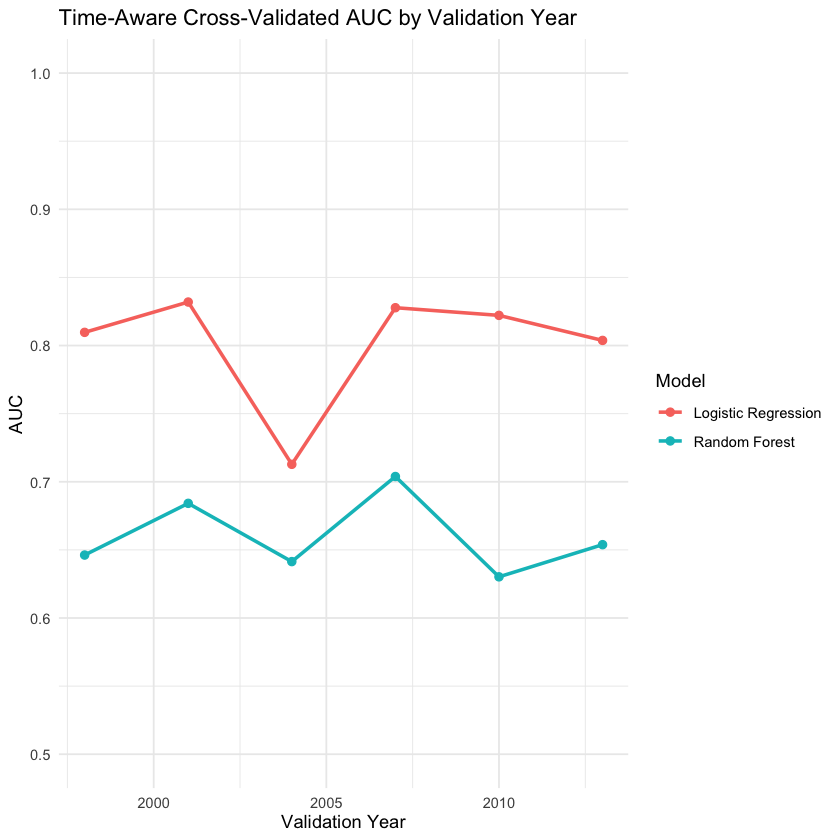

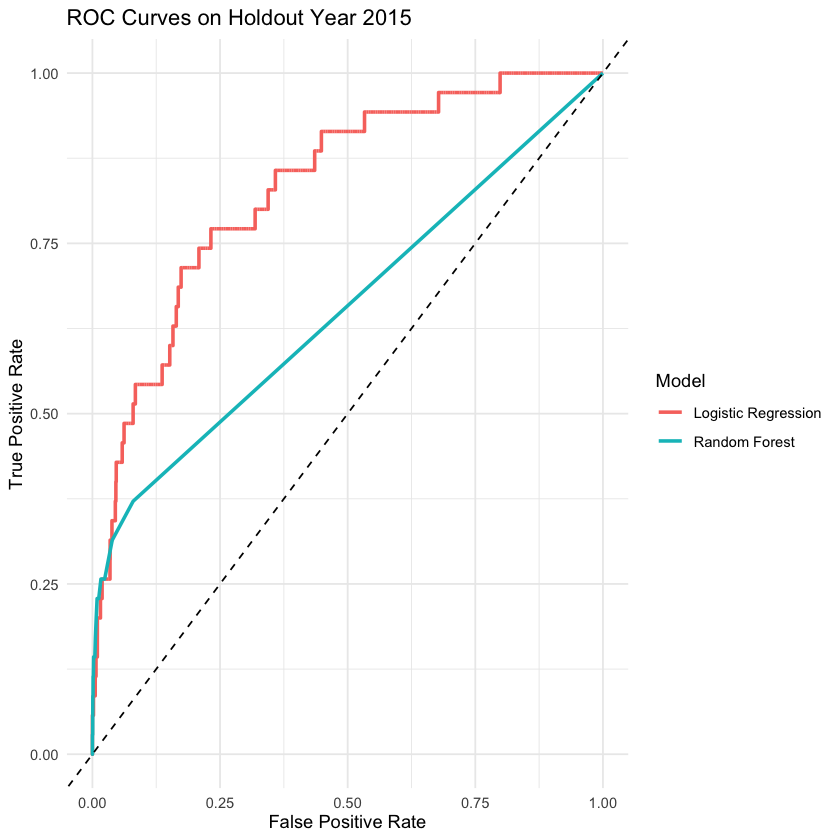

In [11]:
# Time-aware validation:
# train only on earlier years, validate on a later year

years_available <- sort(unique(panel_model$year))

# Use fewer validation years to reduce runtime
cv_years <- years_available[years_available >= (min(years_available) + 5)]
cv_years <- cv_years[seq(1, length(cv_years), by = 3)]

cv_results <- map_dfr(cv_years, function(v_year) {

  train_data <- panel_model %>% filter(year < v_year)
  valid_data <- panel_model %>% filter(year == v_year)

  if (nrow(train_data) == 0 || nrow(valid_data) == 0) {
    return(NULL)
  }

  # Logistic regression on a manageable sample
  set.seed(100 + v_year)
  glm_train <- train_data %>%
    sample_n(min(100000, nrow(train_data))) %>%
    droplevels()

  glm_fit <- glm(glm_formula, data = glm_train, family = binomial())

  glm_prob <- predict(glm_fit, newdata = valid_data, type = "response")
  glm_auc <- as.numeric(auc(valid_data$outcome, glm_prob))

  # Random forest on a smaller sample to avoid memory issues
  set.seed(200 + v_year)
  rf_train <- train_data %>%
    sample_n(min(30000, nrow(train_data))) %>%
    droplevels()

  rf_fit <- randomForest(
    formula = rf_formula,
    data = rf_train,
    ntree = 75,
    mtry = 4,
    importance = FALSE
  )

  rf_prob <- predict(rf_fit, newdata = valid_data, type = "prob")[, "1"]
  rf_auc <- as.numeric(auc(valid_data$outcome, rf_prob))

  tibble(
    validation_year = v_year,
    glm_auc = glm_auc,
    rf_auc = rf_auc
  )
})

cv_results

# Reshape for plotting
cv_long <- cv_results %>%
  pivot_longer(cols = c(glm_auc, rf_auc), names_to = "model", values_to = "auc") %>%
  mutate(
    model = recode(
      model,
      glm_auc = "Logistic Regression",
      rf_auc = "Random Forest"
    )
  )

# Diagnostic plot required by project
ggplot(cv_long, aes(x = validation_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_y_continuous(limits = c(0.5, 1)) +
  labs(
    title = "Time-Aware Cross-Validated AUC by Validation Year",
    x = "Validation Year",
    y = "AUC",
    color = "Model"
  )

# Summary table of AUC values
cv_summary <- cv_long %>%
  group_by(model) %>%
  summarise(
    mean_auc = mean(auc, na.rm = TRUE),
    sd_auc = sd(auc, na.rm = TRUE),
    min_auc = min(auc, na.rm = TRUE),
    max_auc = max(auc, na.rm = TRUE),
    .groups = "drop"
  )

cv_summary

# Train on all years before the last year
# Test on the final year only

final_train <- panel_model %>% filter(year < max(year))
final_test  <- panel_model %>% filter(year == max(year))

# Logistic regression on a manageable sample
set.seed(141)
glm_final_train <- final_train %>%
  sample_n(min(100000, nrow(final_train))) %>%
  droplevels()

glm_final <- glm(glm_formula, data = glm_final_train, family = binomial())

# Random forest on a smaller sample
set.seed(241)
rf_final_train <- final_train %>%
  sample_n(min(30000, nrow(final_train))) %>%
  droplevels()

rf_final <- randomForest(
  formula = rf_formula,
  data = rf_final_train,
  ntree = 75,
  mtry = 4,
  importance = FALSE
)

# Predictions on holdout year
final_test <- final_test %>%
  mutate(
    glm_prob = predict(glm_final, newdata = final_test, type = "response"),
    rf_prob  = predict(rf_final, newdata = final_test, type = "prob")[, "1"]
  )

# Final AUC table
final_auc_table <- tibble(
  model = c("Logistic Regression", "Random Forest"),
  test_year = max(panel_model$year),
  auc = c(
    as.numeric(auc(final_test$outcome, final_test$glm_prob)),
    as.numeric(auc(final_test$outcome, final_test$rf_prob))
  )
)

final_auc_table

# ROC curves for the holdout year
glm_roc <- roc(final_test$outcome, final_test$glm_prob, quiet = TRUE)
rf_roc  <- roc(final_test$outcome, final_test$rf_prob, quiet = TRUE)

roc_df <- bind_rows(
  tibble(
    fpr = 1 - glm_roc$specificities,
    tpr = glm_roc$sensitivities,
    model = "Logistic Regression"
  ),
  tibble(
    fpr = 1 - rf_roc$specificities,
    tpr = rf_roc$sensitivities,
    model = "Random Forest"
  )
)

ggplot(roc_df, aes(x = fpr, y = tpr, color = model)) +
  geom_line(linewidth = 1) +
  geom_abline(linetype = "dashed") +
  labs(
    title = paste("ROC Curves on Holdout Year", max(panel_model$year)),
    x = "False Positive Rate",
    y = "True Positive Rate",
    color = "Model"
  )

This section evaluates how well the models fit historical wildfire data and how well they generalize to future periods. Because the dataset has a strong temporal structure, a time-aware validation approach was used to avoid data leakage. Specifically, for each validation year the models were trained only on data from earlier years and then evaluated on a future year. This ensures that the models do not use information from the future when predicting past events, which would otherwise produce overly optimistic performance estimates. This approach better reflects the real-world prediction task, where models must predict wildfire risk based only on historical data.

Model performance was evaluated using the Area Under the Receiver Operating Characteristic Curve (AUC). The AUC measures how well a model distinguishes between months with a notable wildfire and months without one across all classification thresholds. An AUC value of 0.5 indicates random guessing, while values closer to 1 indicate stronger predictive performance.

The cross-validated results are shown in the validation table and the diagnostic plot of AUC over time. Logistic regression consistently outperformed the random forest model across validation years. The logistic regression model achieved a mean AUC of approximately 0.801, while the random forest achieved a mean AUC of approximately 0.660. Across the validation years shown (1998–2013), logistic regression produced higher AUC values in every evaluation year. The diagnostic plot further illustrates this pattern: the logistic regression curve remains above the random forest curve across the entire validation period. Logistic regression performance ranged from about 0.71 to 0.83, while the random forest ranged from approximately 0.63 to 0.70, indicating weaker discriminatory ability.

A final holdout evaluation was performed using the most recent year in the dataset (2015) as a test set while training both models on all earlier years. The holdout results again show stronger performance from the logistic regression model. Logistic regression achieved an AUC of approximately 0.831, compared with 0.654 for the random forest. The ROC curve for the holdout year further illustrates this difference. The logistic regression curve lies substantially above the random forest curve and the diagonal reference line, indicating better separation between months with and without notable wildfires.

Originally, the evaluation was implemented using a larger and more computationally intensive validation procedure, fitting models on the full training dataset for every validation year. However, this approach required substantial memory and runtime and exceeded the computational limits of the available laptop hardware. To address this limitation, the validation procedure was adjusted by evaluating a subset of validation years and fitting models on large random samples of the training data. These changes significantly reduced computation time while preserving the time-aware validation structure and still allowing a meaningful comparison between models.

Overall, the results suggest that the logistic regression model provides stronger and more consistent predictive performance for this wildfire prediction task. Despite the flexibility of the random forest model, the simpler logistic regression model generalized better across time and achieved higher AUC values both in cross-validation and in the final holdout evaluation.


### 5. Summary

This section summarizes the main findings and contributions of your project. You should summarize the key insights obtained from the exploratory data analysis and explain what your predictive model is able to capture. The discussion should be written for a general audience, emphasizing interpretation and practical understanding rather than technical detail.

**Minimum required output:** Summary of EDA and model performance. 

This project examined patterns in historical wildfire data and developed predictive models to estimate the likelihood that a county would experience a notable wildfire in a given month. Exploratory data analysis showed that wildfire activity varies across both time and geographic location. Some regions consistently experience more wildfire activity than others, and past wildfire history appears to influence the probability of future fires. These observations motivated the creation of predictors based on prior wildfire counts, burned area, and rolling summaries of recent wildfire activity. By aggregating the data into county-by-month units, the analysis captured both spatial patterns and temporal dynamics in wildfire occurrence.

Two predictive models were developed to estimate the probability of a notable wildfire. The baseline model used logistic regression, which provides a simple and interpretable way to model binary outcomes. A second model based on random forests was also trained to explore whether a more flexible machine learning approach could improve prediction accuracy. Both models were evaluated using a time-aware validation procedure in which each model was trained on earlier years and tested on later years. This approach ensured that the models did not use future information when predicting past events and therefore provided a more realistic assessment of predictive performance.

Model performance was measured using the Area Under the ROC Curve (AUC), which evaluates how well the model distinguishes between months with and without notable wildfires. The results showed that the logistic regression model consistently outperformed the random forest model. Across validation years, logistic regression achieved a mean AUC of about 0.80, while the random forest achieved a mean AUC of about 0.66. The final holdout evaluation on the most recent year of data produced similar results, with logistic regression again achieving a higher AUC. The ROC curve for the holdout year also confirmed that logistic regression provided better separation between wildfire and non-wildfire months.

Overall, the results suggest that relatively simple statistical models can capture meaningful patterns in wildfire occurrence when historical wildfire activity is used as a predictor. Although the random forest model is more flexible, it did not improve predictive performance in this case. One possible explanation is that the key relationships in the data are already well captured by the simpler logistic regression model. Additionally, because the dataset is very large, some computational adjustments were required during modeling to ensure the analysis could run efficiently on the available hardware. Despite these constraints, the models still provided useful insight into the factors associated with wildfire risk and demonstrated the potential for data-driven approaches to help understand wildfire patterns over time.